In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split,RandomizedSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

df=pd.read_csv("../../data/final/diabetes_final.csv")
X=df.drop("diabetes",axis=1)
y=df["diabetes"]

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,stratify=y,random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [2]:

models={
"Logistic Regression":LogisticRegression(max_iter=1000),
"Decision Tree":DecisionTreeClassifier(random_state=42),
"Random Forest":RandomForestClassifier(random_state=42),
"SVM":SVC(probability=True),
"KNN":KNeighborsClassifier(),
"Naive Bayes":GaussianNB(),
"XGBoost":XGBClassifier(eval_metric="logloss",random_state=42),
"LightGBM":LGBMClassifier(random_state=42,verbosity=-1),
"CatBoost":CatBoostClassifier(verbose=0,random_state=42)
}

results=[]

for n,m in models.items():
    if n in ["Logistic Regression","SVM","KNN","Naive Bayes"]:
        m.fit(X_train_scaled,y_train)
        pred=m.predict(X_test_scaled)
        proba=m.predict_proba(X_test_scaled)[:,1]
    else:
        m.fit(X_train,y_train)
        pred=m.predict(X_test)
        proba=m.predict_proba(X_test)[:,1]

    results.append([n,
                    accuracy_score(y_test,pred),
                    precision_score(y_test,pred),
                    recall_score(y_test,pred),
                    f1_score(y_test,pred),
                    roc_auc_score(y_test,proba)])

results=pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1","ROC_AUC"])
results=results.sort_values("Accuracy",ascending=False)
display(results)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
7,LightGBM,0.971555,0.976763,0.693986,0.811444,0.977113
6,XGBoost,0.970567,0.960098,0.695165,0.806430,0.976202
8,CatBoost,0.969995,0.948677,0.697524,0.803942,0.975827
2,Random Forest,0.969683,0.950607,0.692217,0.801092,0.958143
3,SVM,0.962871,0.973025,0.595519,0.738844,0.927579
4,KNN,0.960062,0.884743,0.629127,0.735355,0.900514
0,Logistic Regression,0.959438,0.866987,0.637972,0.735054,0.959370
1,Decision Tree,0.948154,0.691928,0.742925,0.716520,0.855882
5,Naive Bayes,0.900988,0.456703,0.646816,0.535383,0.917094


In [3]:

param_dist={
"n_estimators":[100,200,300],
"max_depth":[5,10,20,None],
"min_samples_split":[2,5,10],
"min_samples_leaf":[1,2,4]
}

search=RandomizedSearchCV(
RandomForestClassifier(random_state=42),
param_dist,
cv=5,
n_iter=20,
n_jobs=-1,
random_state=42)

search.fit(X_train,y_train)

best_model=search.best_estimator_
pred=best_model.predict(X_test)
proba=best_model.predict_proba(X_test)[:,1]

print(search.best_params_)
print("Accuracy:",accuracy_score(y_test,pred))


{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': None}
Accuracy: 0.9717628705148206


Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       1.00      0.68      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230



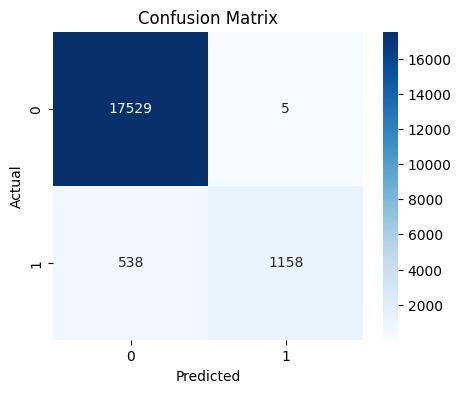

In [4]:

print("Classification Report")
print(classification_report(y_test,pred))

cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


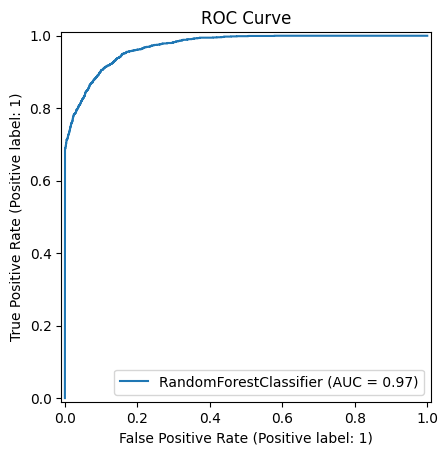

In [5]:

RocCurveDisplay.from_estimator(best_model,X_test,y_test)
plt.title("ROC Curve")
plt.show()


In [6]:

cv_score=cross_val_score(best_model,X,y,cv=5,scoring="accuracy")

print("Cross Validation Scores:",cv_score)
print("Mean Accuracy:",cv_score.mean())


Cross Validation Scores: [0.97103484 0.97155338 0.96884913 0.9717614  0.97077331]
Mean Accuracy: 0.9707944143237673


In [11]:

joblib.dump(best_model,"../../models/best_model_diabetes.pkl")
joblib.dump(scaler,"../../models/scaler_diabetes.pkl")
print("Model and scaler saved.")


Model and scaler saved.
